# Set Working Directory

In [1]:
# Set the working directory
import os
import numpy as np
import pandas as pd

#work_dir = os.path.dirname(os.path.dirname(os.getcwd())) 
work_dir = os.path.dirname(os.getcwd())

print(f"Current working directory: {work_dir}")

Current working directory: c:\Users\dysk-\Desktop\Current task\EEG compe


# Check data

In [9]:
import numpy as np

data_dir = os.path.join(work_dir, "data/train")

X = np.load(os.path.join(data_dir, "eeg.npy"))
y = np.load(os.path.join(data_dir, "labels.npy"))
subj = np.load(os.path.join(data_dir, "subject_idxs.npy"))

print(X.shape)
print(y.shape)
print(subj.shape)

print(np.unique(y))
print(np.unique(subj))

(118800, 17, 100)
(118800,)
(118800,)
[0 1 2 3 4]
[ 1  2  3  4  5  6  7  8  9 10]


In [10]:
for s in np.unique(subj):
    idx = subj == s
    print(s, np.bincount(y[idx]))

1 [2720 4600 1780 1760 1020]
2 [2720 4600 1780 1760 1020]
3 [2720 4600 1780 1760 1020]
4 [2720 4600 1780 1760 1020]
5 [2720 4600 1780 1760 1020]
6 [2720 4600 1780 1760 1020]
7 [2720 4600 1780 1760 1020]
8 [2720 4600 1780 1760 1020]
9 [2720 4600 1780 1760 1020]
10 [2720 4600 1780 1760 1020]


In [11]:
print(X.mean())
print(X.std())

print(X.min())
print(X.max())

-0.05238135226089943
0.8120016590366143
-159.9350961494849
44.24448492364342


# Plot EEG data

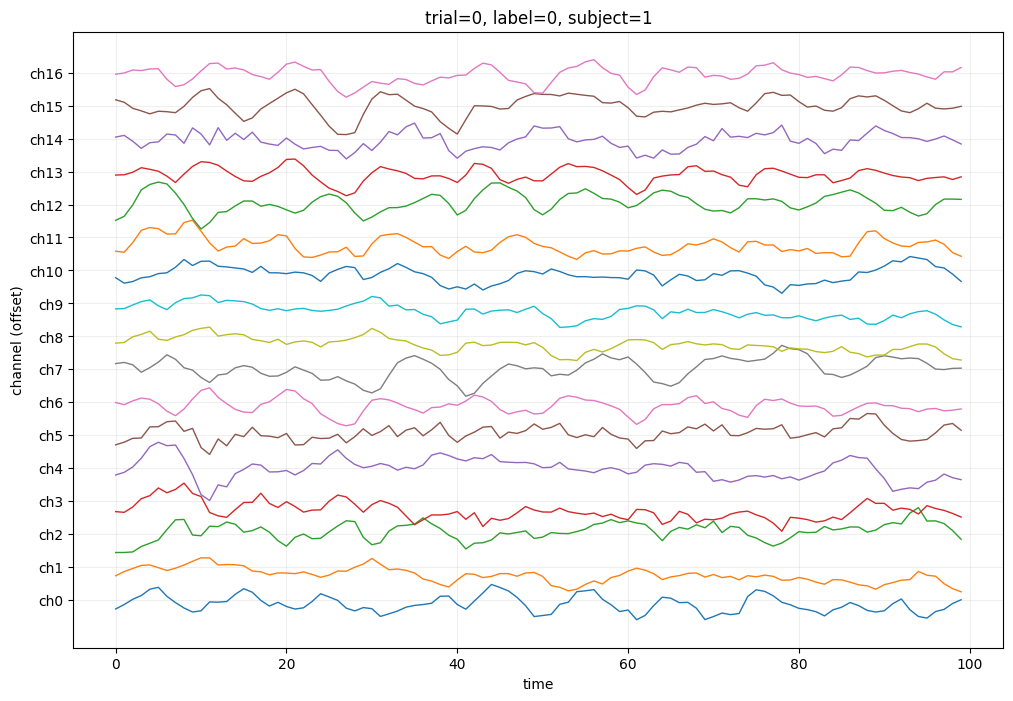

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os

data_dir = os.path.join(work_dir, "data/train")

X = np.load(os.path.join(data_dir, "eeg.npy"))
y = np.load(os.path.join(data_dir, "labels.npy"))
subj = np.load(os.path.join(data_dir, "subject_idxs.npy"))

def plot_eeg_trial(i, scale=3.0):
    x = X[i]  # (17, 100)
    label = y[i]
    s = subj[i]

    plt.figure(figsize=(12, 8))
    for ch in range(x.shape[0]):
        plt.plot(x[ch] + ch * scale, linewidth=1)

    plt.title(f"trial={i}, label={label}, subject={s}")
    plt.xlabel("time")
    plt.ylabel("channel (offset)")
    plt.yticks(np.arange(x.shape[0]) * scale, [f"ch{c}" for c in range(x.shape[0])])
    plt.grid(alpha=0.2)
    plt.show()

plot_eeg_trial(0)

In [3]:
data_dir = os.path.join(work_dir, "data/train")

with open(os.path.join(data_dir, "image_paths.txt")) as f:
    paths = f.readlines()

print(len(paths))

118800


In [4]:
from collections import Counter

paths_clean = [p.strip() for p in paths]
cnt = Counter(paths_clean)

print("unique images:", len(cnt))
print("most common:", cnt.most_common(10))

unique images: 5940
most common: [('00001_aardvark/aardvark_01b.jpg', 20), ('00001_aardvark/aardvark_02s.jpg', 20), ('00001_aardvark/aardvark_03s.jpg', 20), ('00001_aardvark/aardvark_04s.jpg', 20), ('00001_aardvark/aardvark_05s.jpg', 20), ('00001_aardvark/aardvark_06s.jpg', 20), ('00001_aardvark/aardvark_07s.jpg', 20), ('00001_aardvark/aardvark_08s.jpg', 20), ('00001_aardvark/aardvark_09s.jpg', 20), ('00001_aardvark/aardvark_10s.jpg', 20)]


In [10]:
def load_paths(data_dir):
    with open(os.path.join(data_dir, "image_paths.txt")) as f:
        return [p.strip() for p in f.readlines()]
    

traindata_dir = os.path.join(work_dir, "data/train")
valdata_dir = os.path.join(work_dir, "data/val")

train_paths = load_paths(traindata_dir)
val_paths = load_paths(valdata_dir)

train_unique = set(train_paths)
val_unique = set(val_paths)

print("train unique:", len(train_unique))
print("val unique:", len(val_unique))
print("overlap:", len(train_unique & val_unique))

train unique: 5940
val unique: 5940
overlap: 5940


In [12]:
X = np.load(os.path.join(traindata_dir, "eeg.npy"))
y = np.load(os.path.join(traindata_dir, "labels.npy"))
subj = np.load(os.path.join(traindata_dir, "subject_idxs.npy"))

with open(os.path.join(traindata_dir, "image_paths.txt")) as f:
    paths = [p.strip() for p in f.readlines()]

for i in range(30):
    print(i, paths[i], "label=", y[i], "subj=", subj[i])

0 00001_aardvark/aardvark_01b.jpg label= 0 subj= 1
1 00001_aardvark/aardvark_01b.jpg label= 0 subj= 1
2 00001_aardvark/aardvark_02s.jpg label= 0 subj= 1
3 00001_aardvark/aardvark_02s.jpg label= 0 subj= 1
4 00001_aardvark/aardvark_03s.jpg label= 0 subj= 1
5 00001_aardvark/aardvark_03s.jpg label= 0 subj= 1
6 00001_aardvark/aardvark_04s.jpg label= 0 subj= 1
7 00001_aardvark/aardvark_04s.jpg label= 0 subj= 1
8 00001_aardvark/aardvark_05s.jpg label= 0 subj= 1
9 00001_aardvark/aardvark_05s.jpg label= 0 subj= 1
10 00001_aardvark/aardvark_06s.jpg label= 0 subj= 1
11 00001_aardvark/aardvark_06s.jpg label= 0 subj= 1
12 00001_aardvark/aardvark_07s.jpg label= 0 subj= 1
13 00001_aardvark/aardvark_07s.jpg label= 0 subj= 1
14 00001_aardvark/aardvark_08s.jpg label= 0 subj= 1
15 00001_aardvark/aardvark_08s.jpg label= 0 subj= 1
16 00001_aardvark/aardvark_09s.jpg label= 0 subj= 1
17 00001_aardvark/aardvark_09s.jpg label= 0 subj= 1
18 00001_aardvark/aardvark_10s.jpg label= 0 subj= 1
19 00001_aardvark/aard

In [7]:
for split in [traindata_dir, valdata_dir]:
    y = np.load(os.path.join(split, "labels.npy"))
    subj = np.load(os.path.join(split, "subject_idxs.npy"))
    print(os.path.basename(split))
    print("subj:", np.unique(subj, return_counts=True))
    print("label:", np.unique(y, return_counts=True))

train
subj: (array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=int64), array([11880, 11880, 11880, 11880, 11880, 11880, 11880, 11880, 11880,
       11880], dtype=int64))
label: (array([0, 1, 2, 3, 4], dtype=int64), array([27200, 46000, 17800, 17600, 10200], dtype=int64))
val
subj: (array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=int64), array([5940, 5940, 5940, 5940, 5940, 5940, 5940, 5940, 5940, 5940],
      dtype=int64))
label: (array([0, 1, 2, 3, 4], dtype=int64), array([13600, 23000,  8900,  8800,  5100], dtype=int64))


In [8]:
from collections import Counter

train_paths = [p.strip() for p in train_paths]

cnt = Counter(train_paths)

print("unique images:", len(cnt))
print("min repeat:", min(cnt.values()))
print("max repeat:", max(cnt.values()))
print("unique repeats:", set(cnt.values()))

unique images: 5940
min repeat: 20
max repeat: 20
unique repeats: {20}
